# Milo tutorial via **`milor_py`** standalone

Same analysis as `tutorial_omicverse.ipynb` but driving the Milo
class directly — no `omicverse` imports required. Useful if you only
want differential abundance testing without the full omicverse stack.

**Data**: Haber et al. 2017 mouse intestinal epithelium (Control vs
Salmonella).

The Milo pipeline here is the canonical four-step workflow:

1. `make_nhoods` — sample index cells and expand each into its
   k-NN neighbourhood
2. `count_nhoods` — build the (n_nhoods × n_samples) count matrix
3. `da_nhoods` — fit a QL-NB GLM per neighbourhood, return `logFC` +
   `PValue` + spatial-FDR
4. `build_nhood_graph` — overlap-based neighbourhood graph for the
   beeswarm / graph plots


In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import anndata as ad

from milor_py import Milo

adata = ad.read_h5ad('/scratch/users/steorra/analysis/26_omic_protocol/data/haber_2017_regions.h5ad')
adata = adata[adata.obs['condition'].isin(['Control', 'Salmonella'])].copy()
print(adata)
print(adata.obs['condition'].value_counts())

AnnData object with n_obs × n_vars = 5010 × 15215
    obs: 'batch', 'barcode', 'condition', 'cell_label'
condition
Control       3240
Salmonella    1770
Name: count, dtype: int64


## 1. Preprocess + k-NN graph

Standard scanpy pipeline (no omicverse): normalise, PCA, neighbours,
UMAP. The k-NN graph is what Milo operates on in step 2.

In [2]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3',
                             layer=None)
adata = adata[:, adata.var['highly_variable']].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)

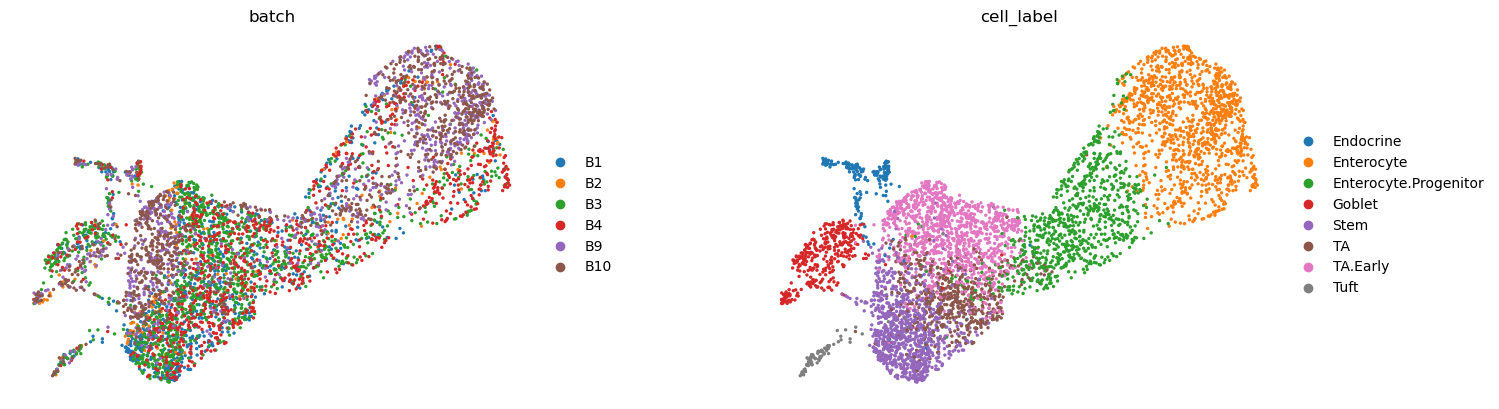

In [3]:
sc.pl.umap(adata, color=['batch', 'cell_label'], frameon=False,
            wspace=0.3, show=False)
plt.show()

## 2. Milo pipeline — direct API

The four core calls. Inputs and outputs are written into a MuData
object so the per-neighbourhood results live alongside the per-cell
AnnData.

In [4]:
m = Milo()

# Wrap the AnnData in a MuData with slots ``rna`` (input) + ``milo``
# (results will be written into this slot).
mdata = m.load(adata)

# 1) Sample 10% of cells as neighbourhood index points. Neighbourhood
#    size is inherited from the ``sc.pp.neighbors(n_neighbors=...)``
#    call above.
m.make_nhoods(mdata, prop=0.1)

# 2) Build the (n_nhoods × n_samples) count matrix; sample labels come from `batch`.
mdata = m.count_nhoods(mdata, sample_col='batch')

# 3) Fit the QL-NB GLM per neighbourhood.
#    ``model_contrasts`` selects the Salmonella − Control contrast.
m.da_nhoods(
    mdata,
    design='~condition',
    model_contrasts='condition[Salmonella]-condition[Control]',
)

# 4) Overlap graph between neighbourhoods for the beeswarm plot.
m.build_nhood_graph(mdata, basis='X_umap')

print(mdata['milo'])
print(mdata['milo'].var[['logFC', 'PValue', 'SpatialFDR']].head())

Using X_pca as default embedding


Calculating TMM normalization factors...
TMM factors: [1.16905954 1.9739836  1.19729991 1.23809725 0.57874833 0.50509419]
Original lib_sizes: [2257  409 3718 2695 2163 2408]
Effective lib_sizes: [2638.56737843  807.35929059 4451.56107229 3336.67208605 1251.83263613
 1216.26680587]
Design matrix columns: ['condition[Control]', 'condition[Salmonella]']
Model contrasts: condition[Salmonella]-condition[Control]
  Contrast term 'condition[Salmonella]' (index 1): +1
  Contrast term 'condition[Control]' (index 0): -1
Contrast vector: [-1.  1.]
✓ Contrast sums to 0 (valid difference contrast)
edgepy result columns: ['logFC', 'lfcSE', 'logCPM', 'stat', 'PValue', 'FDR', 'adj_pvalue']
AnnData object with n_obs × n_vars = 6 × 374
    obs: 'condition', 'batch'
    var: 'index_cell', 'kth_distance', 'logFC', 'lfcSE', 'logCPM', 'stat', 'PValue', 'FDR', 'adj_pvalue', 'SpatialFDR', 'Nhood_size'
    uns: 'sample_col', 'nhood'
    varm: 'X_milo_graph'
    varp: 'nhood_connectivities'
      logFC    PValu

## 3. Annotate neighbourhoods with majority-vote cell type

In [5]:
m.annotate_nhoods(mdata, anno_col='cell_label')
# Mark low-confidence neighbourhoods (< 60 % of cells sharing the
# majority label) as ``Mixed`` — extend the categorical first.
anno = mdata['milo'].var['nhood_annotation']
if hasattr(anno, 'cat') and 'Mixed' not in anno.cat.categories:
    anno = anno.cat.add_categories(['Mixed'])
mix_mask = mdata['milo'].var['nhood_annotation_frac'] < 0.6
anno[mix_mask] = 'Mixed'
mdata['milo'].var['nhood_annotation'] = anno
mdata['milo'].var[['nhood_annotation',
                    'nhood_annotation_frac',
                    'logFC', 'SpatialFDR']].head()

,nhood_annotation,nhood_annotation_frac,logFC,SpatialFDR
0,Stem,0.971429,-1.807466,0.432594
1,Mixed,0.486486,0.977457,0.525413
2,Enterocyte.Progenitor,1.000000,1.191475,0.497351
3,TA.Early,0.883721,-0.258055,0.888527
4,Enterocyte.Progenitor,1.000000,-5.008863,0.313114


## 4. Diagnostics + visualisation

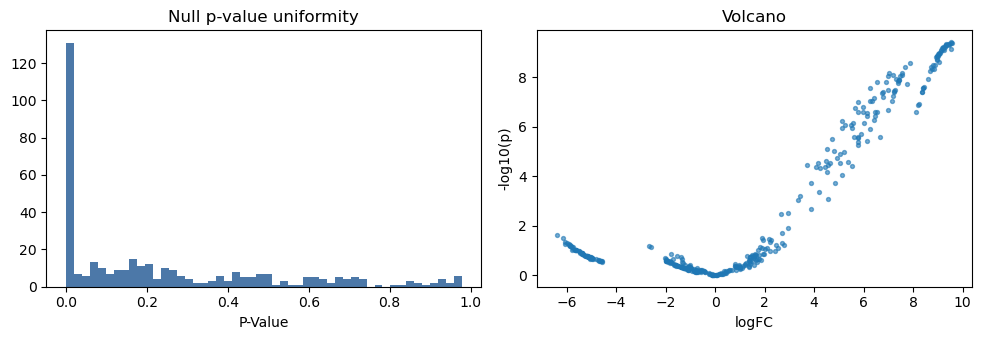

In [6]:
milo_var = mdata['milo'].var
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(milo_var['PValue'], bins=50, color='#4c78a8')
axes[0].set_xlabel('P-Value'); axes[0].set_title('Null p-value uniformity')
axes[1].scatter(milo_var['logFC'], -np.log10(milo_var['PValue']),
                 s=8, alpha=0.6)
axes[1].set_xlabel('logFC'); axes[1].set_ylabel('-log10(p)')
axes[1].set_title('Volcano')
plt.tight_layout(); plt.show()

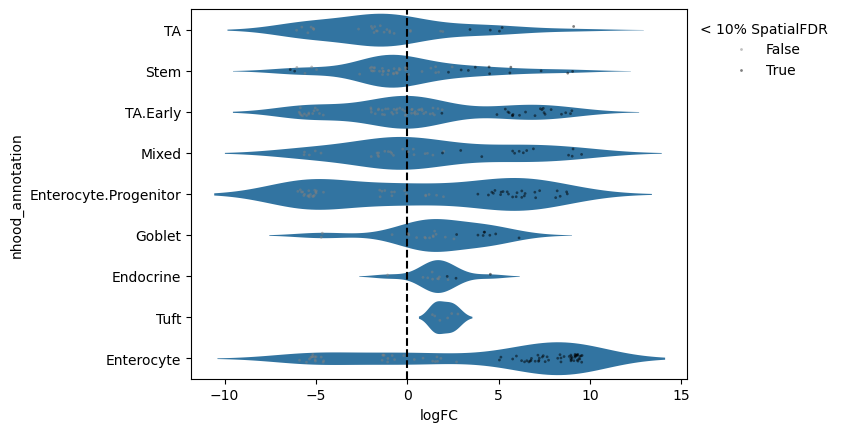

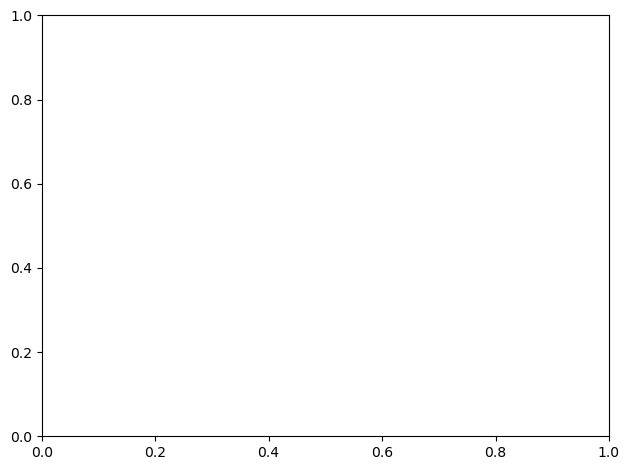

In [7]:
m.plot_da_beeswarm(mdata, alpha=0.1)
plt.xticks(fontsize=10); plt.yticks(fontsize=10); plt.tight_layout()

## Summary

The standalone API mirrors the miloR R workflow 1-for-1:

```python
from milor_py import Milo
m = Milo()
mdata = m.load(adata)            # AnnData → MuData with 'rna' + 'milo' slots
m.make_nhoods(mdata, prop=0.1)
mdata = m.count_nhoods(mdata, sample_col='batch')
m.da_nhoods(mdata, design='~condition',
             model_contrasts='condition[Salmonella]-condition[Control]')
m.build_nhood_graph(mdata, basis='X_umap')
m.annotate_nhoods(mdata, anno_col='cell_label')
```

The class you just used is the **same code path** as
`ov.single.DCT(method='milopy')` in the omicverse tutorial — omicverse
is the upstream development home, and this repo mirrors the Milo class
with zero functional diff.